# Stage 8 (Optional Extension) - Price the customer product

**Input:** only files that were genuinely available on the futures quote date, 29 September 2023 -
the forecast load (`data/forecast_load.csv`, Stage 1), the HPFC (`data/hpfc.csv`, Stage 2), and the
hedge positions/energy for all three strategies (`data/hedge_positions.csv`,
`data/hedge_energy.csv`, `data/selected_products.csv`, Stage 3).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

DATA = "../data"
DT = 0.25
STRATEGIES = ["UNHEDGED", "COARSE_CAL", "GRANULAR"]
COLORS = {"UNHEDGED": "#8172B3", "COARSE_CAL": "#DD8452", "GRANULAR": "#4C72B0"}
HEDGE_COL = {"UNHEDGED": "hedge_unhedged_mwh", "COARSE_CAL": "hedge_coarse_cal_mwh", "GRANULAR": "hedge_granular_mwh"}

forecast = pd.read_csv(f"{DATA}/forecast_load.csv")
hpfc     = pd.read_csv(f"{DATA}/hpfc.csv")
energy   = pd.read_csv(f"{DATA}/hedge_energy.csv")
positions = pd.read_csv(f"{DATA}/hedge_positions.csv")
selected  = pd.read_csv(f"{DATA}/selected_products.csv")

df = forecast.merge(hpfc, on="timestamp_utc").rename(columns={"total": "L"})
df = df.merge(energy[["timestamp_utc"] + list(HEDGE_COL.values())], on="timestamp_utc")
print("merged grid:", df.shape, "-> forecast load (Stage 1) x HPFC (Stage 2) x hedge energy (Stage 3)")
print("all three inputs were fixed on or before 29 Sep 2023 - nothing here depends on how 2024 turned out")

merged grid: (35136, 11) -> forecast load (Stage 1) x HPFC (Stage 2) x hedge energy (Stage 3)
all three inputs were fixed on or before 29 Sep 2023 - nothing here depends on how 2024 turned out


## 1. What was known on 29 September 2023, and what was not

A transparent price can only use information that genuinely existed at the offer date.

In [2]:
info = pd.DataFrame({
    "Known ex-ante (usable for pricing)": [
        "Customer table, SLP profiles (Stage 1)",
        "Futures snapshot + market_activity (Stage 2)",
        "Historical 2019-2022 price *shape* (Stage 2)",
        "HPFC, hedge optimisation, positions (Stage 2-3)",
    ],
    "Known only ex-post (2024, not usable)": [
        "actual_portfolio_load.csv - realised consumption",
        "day_ahead_prices.csv - realised Day-Ahead prices",
        "imbalance_prices.csv - realised reBAP",
        "All Stage 4-7 results (cost, saving, Dec event)",
    ],
})
info

,Known ex-ante (usable for pricing),"Known only ex-post (2024, not usable)"
0,"Customer table, SLP profiles (Stage 1)",actual_portfolio_load.csv - realised consumption
1,Futures snapshot + market_activity (Stage 2),day_ahead_prices.csv - realised Day-Ahead prices
2,Historical 2019-2022 price *shape* (Stage 2),imbalance_prices.csv - realised reBAP
3,"HPFC, hedge optimisation, positions (Stage 2-3)","All Stage 4-7 results (cost, saving, Dec event)"


## 2. Base procurement cost - fully ex-ante, no assumption needed

The HPFC already prices every quarter-hour of 2024 using only information available on
29 September 2023: traded Base/Peak quotes and a *historical* price shape. Valuing the forecast
load at the HPFC therefore gives an ex-ante, market-consistent cost estimate that requires no
knowledge of what 2024 actually did:

$$P_{base} = \frac{\sum_t L_t \cdot HPFC_t}{\sum_t L_t}$$

In [3]:
L_total = df["L"].sum()
load_value = (df["L"] * df["hpfc_eur_mwh"]).sum()
P_base = load_value / L_total

print(f"Forecast energy (Stage 1):     {L_total:,.2f} MWh")
print(f"HPFC value of the load:        {load_value:,.2f} EUR")
print(f"Load-weighted average HPFC:    {P_base:,.2f} EUR/MWh   <- this is P_base")

Forecast energy (Stage 1):     43,000.00 MWh
HPFC value of the load:        3,493,705.92 EUR
Load-weighted average HPFC:    81.25 EUR/MWh   <- this is P_base


## 3. Residual shape risk - the size is known ex-ante, its EUR cost is not

The recommended hedge, COARSE_CAL, is value-neutral against the HPFC, but it does not track the
load shape exactly. The size of that mismatch is fully computable now, from Stage 3 outputs alone.

In [4]:
rows = []
for s in STRATEGIES:
    H = df[HEDGE_COL[s]]
    R = df["L"] - H
    rows.append({
        "strategy": s,
        "hedge_notional_MWh": H.sum(),
        "abs_residual_MWh": R.abs().sum(),
        "abs_residual_pct_of_load": 100 * R.abs().sum() / L_total,
        "residual_RMSE_MWh_per_qh": np.sqrt((R ** 2).mean()),
        "residual_HPFC_value_EUR": (R * df["hpfc_eur_mwh"]).sum(),
    })
shape_risk = pd.DataFrame(rows).set_index("strategy").reindex(STRATEGIES)

assert np.allclose(shape_risk.loc[["COARSE_CAL", "GRANULAR"], "residual_HPFC_value_EUR"], 0, atol=1e-3), \
    "value-neutral strategies must price the residual at exactly zero under the HPFC"
print("Check passed: for COARSE_CAL and GRANULAR, the HPFC-value of the residual is 0.00 EUR by")
print("construction (value neutrality) - the shape mismatch is a volume risk, not a value gap.")
shape_risk

Check passed: for COARSE_CAL and GRANULAR, the HPFC-value of the residual is 0.00 EUR by
construction (value neutrality) - the shape mismatch is a volume risk, not a value gap.


,hedge_notional_MWh,abs_residual_MWh,abs_residual_pct_of_load,residual_RMSE_MWh_per_qh,residual_HPFC_value_EUR
strategy,,,,,
UNHEDGED,0.00,"43,000.00",100.00,1.32,"3,493,705.92"
COARSE_CAL,"44,503.82","12,760.13",29.67,0.44,0.00
GRANULAR,"44,079.18","11,985.15",27.87,0.42,0.00


**What this means for pricing.** The residual volume (about 29.67% of load for COARSE_CAL) still
has to be bought or sold on the Day-Ahead market once 2024 arrives, at whatever price then
prevails. That is a real risk the retailer is taking on, and a transparent price should include a
premium for it. But *sizing that premium in EUR/MWh* requires the **absolute historical volatility**
of Day-Ahead prices around the HPFC shape - and `shape_factors.csv` only supplies a *normalised*
shape (annual mean 1), not historical EUR/MWh levels. This is a genuine information gap: without a
historical absolute price series (e.g. 2019-2022 Day-Ahead prices in EUR/MWh, not just their shape),
this premium cannot be derived from the data provided here and would have to come from the retailer's
risk desk.

## 4. Volume / forecast risk - no ex-ante information available at all

Stage 5 quantifies imbalance risk using `imbalance_prices.csv` and `actual_portfolio_load.csv` -
both realised 2024 series. On 29 September 2023 neither existed yet. Nothing in the case data
provided for this exercise gives a historical reBAP series or a historical forecast-error record
that could be used to estimate this premium ex-ante. This is the largest information gap of the
four components: it cannot be sized from the data at all, only assumed from outside experience
(e.g. a retailer's own multi-year settlement history).

## 5. Trading costs and margin

Consistent with the limitation already noted in the main report (Section 4.2): transaction costs,
bid-ask spreads and collateral funding are not modelled anywhere in this case study and would need
to be added from the retailer's own cost accounting. The commercial margin (profit, overheads,
customer credit risk) is a business decision, not something derivable from market data.

## 6. A transparent pricing formula

$$P_{fixed} = P_{base} + \pi_{shape} + \pi_{volume} + \pi_{trading} + \text{margin}$$

Only $P_{base}$ follows from the data. The other four terms are named explicitly rather than
guessed; the numbers below are **illustrative placeholders** to show how the formula combines, not
a claim about what they should be.

In [5]:
P_base_val   = P_base
pi_shape     = 4.00     # ILLUSTRATIVE - needs historical absolute DA volatility (Section 3)
pi_volume    = 3.00     # ILLUSTRATIVE - needs historical reBAP / forecast-error data (Section 4)
pi_trading   = 0.75     # ILLUSTRATIVE - transaction costs / collateral funding (Section 5)
margin       = 4.00     # ILLUSTRATIVE - commercial margin, business decision (Section 5)

price_build = pd.DataFrame({
    "component": ["P_base (data-derived)", "pi_shape (assumed)", "pi_volume (assumed)",
                  "pi_trading (assumed)", "margin (business decision)"],
    "EUR/MWh": [P_base_val, pi_shape, pi_volume, pi_trading, margin],
})
price_build.loc["TOTAL"] = ["P_fixed (illustrative)", price_build["EUR/MWh"].sum()]
price_build

,component,EUR/MWh
0,P_base (data-derived),81.25
1,pi_shape (assumed),4.00
2,pi_volume (assumed),3.00
3,pi_trading (assumed),0.75
4,margin (business decision),4.00
TOTAL,P_fixed (illustrative),93.00


**Read this table as a structure, not a result.** Row 1 (81.25 EUR/MWh) is the only entry this
report can actually defend from the data. The illustrative total of roughly 93 EUR/MWh only shows
how the pieces would stack up if those assumptions were confirmed by the retailer's risk desk.

## 7. How the recommended hedge changes the answer

In [6]:
# Expected procurement cost PER MWh OF LOAD (not per MWh of hedge notional - hedge and load
# volumes differ by exactly the residual, so dividing by hedge notional would mix the Section-3
# shape mismatch back into what should be a pure price comparison). For COARSE_CAL/GRANULAR,
# C_futures = load_value by value neutrality; for UNHEDGED, the HPFC is itself the unbiased
# ex-ante price forecast, so the expected cost of buying unhedged is the same load valuation.
strategy_comparison = pd.read_csv(f"{DATA}/strategy_comparison.csv").set_index("strategy")

compare = pd.DataFrame({"P_base (EUR/MWh)": {s: P_base_val for s in STRATEGIES}})
compare["abs_residual_pct_of_load"] = shape_risk["abs_residual_pct_of_load"]
compare["monthly_price_std_EUR_per_MWh (Stage 6)"] = strategy_comparison["monthly_price_std_EUR_per_MWh"]
compare

,P_base (EUR/MWh),abs_residual_pct_of_load,monthly_price_std_EUR_per_MWh (Stage 6)
UNHEDGED,81.25,100.00,20.15
COARSE_CAL,81.25,29.67,2.43
GRANULAR,81.25,27.87,18.56


**The expected price is identical across strategies; only the risk around it differs.** This is not
approximate - it follows exactly from the value-neutrality constraint in the Stage 3 hedge
optimisation ($\sum_t H_t \cdot HPFC_t = \sum_t L_t \cdot HPFC_t$): whatever the hedge decision,
the *expected* procurement cost per MWh of load is 81.25 EUR/MWh, because the HPFC is the ex-ante
unbiased price forecast for every quarter-hour, hedged or not. What differs sharply is how much risk
premium the retailer would need to stack on top to confidently stand behind that expected price for
a year: Stage 6 already showed COARSE_CAL's realised monthly-price volatility is about eight times
lower than GRANULAR's and far below UNHEDGED's. A retailer offering COARSE_CAL-backed supply can
therefore justify a *smaller* $\pi_{shape}$ than one backed by GRANULAR or, especially, by no hedge
at all - the hedge choice buys down the size of the risk premium, not the expected cost itself. This
is the same conclusion as the main report's recommendation (Section 3.7), now applied to the
customer price rather than the internal cost comparison.

## 8. Conclusion

An ex-ante-defensible fixed price for the 2024 portfolio has one solid, data-derived anchor -
**81.25 EUR/MWh**, the forecast load valued at the 29 September 2023 HPFC - plus three components
that this case study's data cannot size (a shape-risk premium, a volume/forecast-risk premium, and
trading costs) and one that is a pure business decision (margin). Any number quoted for those four
components in this notebook is illustrative only. What *is* a firm, data-grounded conclusion is
that choosing COARSE_CAL over GRANULAR or UNHEDGED lets the retailer offer the same central price
with a materially smaller risk premium, because it is the strategy with by far the most stable
realised monthly cost (Stage 6). Any comparison of this ex-ante price against what 2024 actually
cost (Stage 4-7) is a backtest of the pricing decision, not part of the pricing decision itself,
and the two must not be conflated.

---

# Extension 2 - Test another hedge design (QUARTER_ONLY)

**Input:** the forecast load (`data/forecast_load.csv`, Stage 1), the HPFC (`data/hpfc.csv`,
Stage 2), the realised Day-Ahead price (`data/day_ahead_prices.csv`), the raw futures quotes
(`data/futures_prices.csv` - for the Q1 Base/Peak quotes that Stage 2/3 did not select, since
GRANULAR covers Q1 with M01/M02/M03 instead), the Stage 3 hedge energy for the three main
strategies (`data/hedge_energy.csv`), and the finished cost comparison
(`data/final_costs.csv`, Stage 6/7).

**Output:** a fourth strategy, `QUARTER_ONLY`, built with the identical Stage 3/4 methodology, plus
`data/quarter_only_positions.csv` and `data/quarter_only_costs.csv`.


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

DATA = "../data"
DT = 0.25   # quarter-hour, in hours
COLORS = {"UNHEDGED": "#8172B3", "COARSE_CAL": "#DD8452", "GRANULAR": "#4C72B0", "QUARTER_ONLY": "#55A868"}

forecast  = pd.read_csv(f"{DATA}/forecast_load.csv")
hpfc      = pd.read_csv(f"{DATA}/hpfc.csv")
day_ahead = pd.read_csv(f"{DATA}/day_ahead_prices.csv")
futures   = pd.read_csv(f"{DATA}/futures_prices.csv")
energy    = pd.read_csv(f"{DATA}/hedge_energy.csv")
final_costs_main = pd.read_csv(f"{DATA}/final_costs.csv").set_index("strategy")

df = forecast.merge(hpfc, on="timestamp_utc", validate="one_to_one")
df = df.merge(day_ahead[["timestamp_utc", "day_ahead_price_eur_mwh"]], on="timestamp_utc", validate="one_to_one")
df = df.merge(energy[["timestamp_utc", "hedge_unhedged_mwh", "hedge_coarse_cal_mwh", "hedge_granular_mwh"]],
              on="timestamp_utc", validate="one_to_one")
df = df.rename(columns={"total": "L", "hpfc_eur_mwh": "HPFC"})
df["t_local"] = pd.to_datetime(df["timestamp_utc"], utc=True).dt.tz_convert("Europe/Berlin")

print("merged grid:", df.shape, "-> forecast load (Stage 1) x HPFC (Stage 2) x realised Day-Ahead price x Stage 3 hedge energy")
df.head()

merged grid: (35136, 13) -> forecast load (Stage 1) x HPFC (Stage 2) x realised Day-Ahead price x Stage 3 hedge energy


,timestamp_utc,HB,GB,LB,L,period,is_peak,HPFC,day_ahead_price_eur_mwh,hedge_unhedged_mwh,hedge_coarse_cal_mwh,hedge_granular_mwh,t_local
0,2023-12-31T23:00:00Z,0.95,0.09,0.03,1.08,M01,0,59.92,0.10,0.00,1.10,1.26,2024-01-01 00:00:00+01:00
1,2023-12-31T23:15:00Z,0.88,0.09,0.03,1.00,M01,0,59.92,0.10,0.00,1.10,1.26,2024-01-01 00:15:00+01:00
2,2023-12-31T23:30:00Z,0.81,0.09,0.03,0.93,M01,0,59.92,0.10,0.00,1.10,1.26,2024-01-01 00:30:00+01:00
3,2023-12-31T23:45:00Z,0.75,0.08,0.03,0.87,M01,0,59.92,0.10,0.00,1.10,1.26,2024-01-01 00:45:00+01:00
4,2024-01-01T00:00:00Z,0.69,0.08,0.03,0.80,M01,0,57.31,0.01,0.00,1.10,1.26,2024-01-01 01:00:00+01:00


## 1. Build the QUARTER_ONLY blocks

Q1-Q4 must tile the year exactly once - the same non-overlap requirement GRANULAR's six blocks
satisfy. `QUARTER_ONLY` differs from `GRANULAR` in exactly one place: Q1 is kept as a single
quarter block instead of being split into M01/M02/M03. Everywhere else (Q2, Q3, Q4) the two
strategies use the identical blocks - so this extension isolates the effect of that one design
choice, rather than testing an unrelated hedge structure.

In [8]:
quarters = futures[(futures["product_type"] == "QUARTER") & (futures["load_type"] == "BASE")] \
    .drop_duplicates("delivery_period")[["delivery_period", "delivery_start", "delivery_end_exclusive"]]

quarter_label = pd.Series(index=df.index, dtype=object)
for _, r in quarters.iterrows():
    start = pd.Timestamp(r["delivery_start"], tz="Europe/Berlin")
    end   = pd.Timestamp(r["delivery_end_exclusive"], tz="Europe/Berlin")
    quarter_label[(df["t_local"] >= start) & (df["t_local"] < end)] = r["delivery_period"]
df["quarter"] = quarter_label

assert df["quarter"].isna().sum() == 0, "gap in the Q1-Q4 tiling"
print("quarter-hours per quarter (tiles the year exactly once, no gaps):")
df["quarter"].value_counts().reindex(["Q1", "Q2", "Q3", "Q4"])

quarter-hours per quarter (tiles the year exactly once, no gaps):


quarter
Q1    8732
Q2    8736
Q3    8832
Q4    8836
Name: count, dtype: int64

## 2. Is Q1 liquid enough to trade?

Stage 2 built the curve from GRANULAR (which skips the Q1 quarter product) without a stated
liquidity reason; before using it here, check its `market_activity` against the quarters
GRANULAR already trades.

In [9]:
q_products = futures[(futures["product_type"] == "QUARTER") & (futures["quote_date"] == "2023-09-29")]
q_products = q_products[["load_type", "delivery_period", "price_eur_mwh", "market_activity"]] \
    .sort_values(["delivery_period", "load_type"]).reset_index(drop=True)
q_products

,load_type,delivery_period,price_eur_mwh,market_activity
0,BASE,Q1,66.42,3000
1,PEAK,Q1,77.70,840
2,BASE,Q2,66.23,2200
3,PEAK,Q2,64.76,616
4,BASE,Q3,74.74,1600
5,PEAK,Q3,69.07,448
6,BASE,Q4,101.39,1400
7,PEAK,Q4,134.42,392


**Q1 is comfortably liquid.** Q1 Base (3,000) and Peak (840) both have *higher* market activity
than Q2 Base/Peak (2,200 / 616), which GRANULAR already trades directly - there is no liquidity
reason Q1 could not be hedged as a single quarter block instead of three months.

## 3. Size the hedge - identical methodology to Stage 3

Within each block, size a Base and a Peak position that is **value-neutral** against the forecast
load (priced at the HPFC), and - among all value-neutral positions - **minimizes the remaining
shape mismatch**. `solve_block` below is copied unchanged from Stage 3.

In [10]:
def solve_block(sub):
    """Value-neutral, shape-minimizing (x_base, x_peak) >= 0 for one block. Identical to Stage 3."""
    L, P, ip = sub["L"].values, sub["HPFC"].values, sub["is_peak"].values.astype(float)
    S_all, S_peak, V_load = P.sum(), (P * ip).sum(), (L * P).sum()

    def objective(x):
        H = DT * (x[0] + x[1] * ip)
        return np.sum((L - H) ** 2)

    def objective_grad(x):
        H = DT * (x[0] + x[1] * ip)
        r = L - H
        return np.array([np.sum(-2 * DT * r), np.sum(-2 * DT * ip * r)])

    def value_gap(x):
        return DT * (x[0] * S_all + x[1] * S_peak) - V_load

    x0 = np.array([L.mean() / DT, 0.0])   # start at "all Base, no Peak"
    res = minimize(
        objective, x0, jac=objective_grad, method="SLSQP",
        constraints=[{"type": "eq", "fun": value_gap, "jac": lambda x: np.array([DT * S_all, DT * S_peak])}],
        bounds=[(0, None), (0, None)],
        options={"ftol": 1e-14, "maxiter": 500},
    )
    assert res.success, res.message
    x_base, x_peak = res.x
    H = DT * (x_base + x_peak * ip)
    return x_base, x_peak, H, value_gap(res.x)


df["H_QUARTER_ONLY"] = 0.0
q_positions = []
for q in ["Q1", "Q2", "Q3", "Q4"]:
    rows = df.index[df["quarter"] == q]
    x_base, x_peak, H, err = solve_block(df.loc[rows])
    df.loc[rows, "H_QUARTER_ONLY"] = H
    q_positions.append({"strategy": "QUARTER_ONLY", "block": q,
                         "x_base_MW": x_base, "x_peak_MW": x_peak, "value_gap_EUR": err})

q_positions = pd.DataFrame(q_positions)
assert np.allclose(q_positions["value_gap_EUR"], 0, atol=1e-6), "value neutrality violated somewhere"
assert (q_positions[["x_base_MW", "x_peak_MW"]] >= 0).all().all(), "a position went short"
print("all positions >= 0 (bound never binds); value neutrality holds in every block (max |gap| = "
      f"{q_positions['value_gap_EUR'].abs().max():.2e} EUR)")
q_positions

all positions >= 0 (bound never binds); value neutrality holds in every block (max |gap| = 0.00e+00 EUR)


,strategy,block,x_base_MW,x_peak_MW,value_gap_EUR
0,QUARTER_ONLY,Q1,4.89,2.19,0.00
1,QUARTER_ONLY,Q2,4.00,1.68,0.00
2,QUARTER_ONLY,Q3,3.85,1.54,0.00
3,QUARTER_ONLY,Q4,4.66,2.13,0.00


## 4. Hedge quality vs. the three main strategies

In [11]:
HEDGE_COL = {"UNHEDGED": "hedge_unhedged_mwh", "COARSE_CAL": "hedge_coarse_cal_mwh",
             "GRANULAR": "hedge_granular_mwh", "QUARTER_ONLY": "H_QUARTER_ONLY"}
ALL_STRATEGIES = ["UNHEDGED", "COARSE_CAL", "GRANULAR", "QUARTER_ONLY"]

diag = pd.DataFrame({
    s: {
        "hedge_notional_MWh":  df[HEDGE_COL[s]].sum(),
        "load_MWh":            df["L"].sum(),
        "hedge_value_EUR":     (df[HEDGE_COL[s]] * df["HPFC"]).sum(),
        "load_value_EUR":      (df["L"] * df["HPFC"]).sum(),
        "rmse_MWh_per_qh":     np.sqrt(np.mean((df["L"] - df[HEDGE_COL[s]]) ** 2)),
        "residual_volume_MWh": np.sum(np.abs(df["L"] - df[HEDGE_COL[s]])),
    }
    for s in ALL_STRATEGIES
}).T
diag["value_gap_EUR"] = diag["hedge_value_EUR"] - diag["load_value_EUR"]

assert np.allclose(diag.loc[["COARSE_CAL", "GRANULAR", "QUARTER_ONLY"], "value_gap_EUR"], 0, atol=1e-3)
diag

,hedge_notional_MWh,load_MWh,hedge_value_EUR,load_value_EUR,rmse_MWh_per_qh,residual_volume_MWh,value_gap_EUR
UNHEDGED,0.00,"43,000.00",0.00,"3,493,705.92",1.32,"43,000.00","-3,493,705.92"
COARSE_CAL,"44,503.82","43,000.00","3,493,705.92","3,493,705.92",0.44,"12,760.13",-0.00
GRANULAR,"44,079.18","43,000.00","3,493,705.92","3,493,705.92",0.42,"11,985.15",-0.00
QUARTER_ONLY,"44,108.24","43,000.00","3,493,705.92","3,493,705.92",0.42,"12,004.94",-0.00


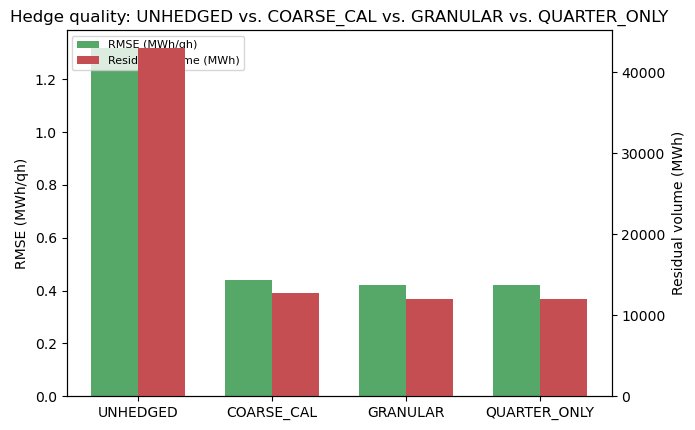

In [12]:
x = np.arange(len(diag)); width = 0.35
fig, ax = plt.subplots(figsize=(7, 4.4))
ax2 = ax.twinx()
b1 = ax.bar(x - width / 2, diag["rmse_MWh_per_qh"], width, color="#55A868", label="RMSE (MWh/qh)")
b2 = ax2.bar(x + width / 2, diag["residual_volume_MWh"], width, color="#C44E52", label="Residual volume (MWh)")
ax.set_xticks(x); ax.set_xticklabels(diag.index)
ax.set_ylabel("RMSE (MWh/qh)"); ax2.set_ylabel("Residual volume (MWh)")
ax.set_title("Hedge quality: UNHEDGED vs. COARSE_CAL vs. GRANULAR vs. QUARTER_ONLY")
ax.legend([b1, b2], [b1.get_label(), b2.get_label()], fontsize=8, loc="upper left")

plt.tight_layout(); plt.show()

**Comment.** `QUARTER_ONLY` sits between `COARSE_CAL` and `GRANULAR`, and very close to the
latter - as expected, since the two are identical outside Q1. Replacing GRANULAR's three Q1
month-blocks with one Q1 quarter-block gives up only a small amount of shape fit for a
meaningfully simpler position (8 traded series instead of 12).

## 5. Price it through Day-Ahead shaping - identical methodology to Stage 4

Fixed futures cost per block, plus the residual bought/sold at the realised Day-Ahead price:

$$C_{futures} = \Delta t \sum_b \Big( x_{base,b} \cdot N_{all,b} \cdot P_{base,b} \;+\; x_{peak,b} \cdot N_{peak,b} \cdot P_{peak,b} \Big), \qquad C_{residual}^{DA} = \sum_t (L_t - H_t) \cdot P_t^{DA}$$

In [13]:
counts = df.groupby("quarter")["is_peak"].agg(N_all="size", N_peak="sum")

price_base = q_products[q_products["load_type"] == "BASE"].set_index("delivery_period")["price_eur_mwh"]
price_peak = q_products[q_products["load_type"] == "PEAK"].set_index("delivery_period")["price_eur_mwh"]

q_pos = q_positions.copy()
q_pos["N_all"]  = q_pos["block"].map(counts["N_all"])
q_pos["N_peak"] = q_pos["block"].map(counts["N_peak"])
q_pos["P_base"] = q_pos["block"].map(price_base)
q_pos["P_peak"] = q_pos["block"].map(price_peak)
q_pos["C_futures_block"] = DT * (q_pos["x_base_MW"] * q_pos["N_all"] * q_pos["P_base"]
                                  + q_pos["x_peak_MW"] * q_pos["N_peak"] * q_pos["P_peak"])

C_futures_Q = q_pos["C_futures_block"].sum()
R_DA_Q = df["L"] - df["H_QUARTER_ONLY"]
C_residual_DA_Q = (R_DA_Q * df["day_ahead_price_eur_mwh"]).sum()
C_forecast_Q = C_futures_Q + C_residual_DA_Q

print(f"C_futures (QUARTER_ONLY):     {C_futures_Q:,.2f} EUR")
print(f"C_residual_DA (QUARTER_ONLY): {C_residual_DA_Q:,.2f} EUR")
print(f"C_forecast (QUARTER_ONLY):    {C_forecast_Q:,.2f} EUR")
q_pos[["strategy", "block", "x_base_MW", "x_peak_MW", "N_all", "N_peak", "P_base", "P_peak", "C_futures_block"]]

C_futures (QUARTER_ONLY):     3,493,657.78 EUR
C_residual_DA (QUARTER_ONLY): -42,235.23 EUR
C_forecast (QUARTER_ONLY):    3,451,422.55 EUR


,strategy,block,x_base_MW,x_peak_MW,N_all,N_peak,P_base,P_peak,C_futures_block
0,QUARTER_ONLY,Q1,4.89,2.19,8732,3120,66.42,77.70,"840,816.77"
1,QUARTER_ONLY,Q2,4.00,1.68,8736,3120,66.23,64.76,"663,355.19"
2,QUARTER_ONLY,Q3,3.85,1.54,8832,3168,74.74,69.07,"719,370.73"
3,QUARTER_ONLY,Q4,4.66,2.13,8836,3168,101.39,134.42,"1,270,115.09"


## 6. Add realised imbalance cost and compare all four strategies

`final_costs.csv` (Stage 6/7) shows `C_imb_EUR` and `Premium_imb_EUR` are **identical** across
`UNHEDGED`, `COARSE_CAL`, and `GRANULAR`. That is not a coincidence: Stage 4's Day-Ahead shaping
always reconciles the futures hedge to deliver exactly the *forecast* load, for every strategy -
so the physical schedule handed to Stage 5 is strategy-independent, and imbalance (actual vs.
forecast load) is too. `QUARTER_ONLY` follows the same logic, so the two imbalance figures are
reused rather than re-derived.

In [14]:
assert final_costs_main["C_imb_EUR"].nunique() == 1 and final_costs_main["Premium_imb_EUR"].nunique() == 1, \
    "imbalance cost is expected to be strategy-independent (Stage 4 always delivers the forecast load)"
C_imb, Premium_imb = final_costs_main["C_imb_EUR"].iloc[0], final_costs_main["Premium_imb_EUR"].iloc[0]

quarter_only_row = pd.Series({
    "C_futures_EUR":      C_futures_Q,
    "C_residual_DA_EUR":  C_residual_DA_Q,
    "C_forecast_EUR":     C_forecast_Q,
    "C_imb_EUR":          C_imb,
    "Premium_imb_EUR":    Premium_imb,
    "C_final_EUR":        C_forecast_Q + C_imb + Premium_imb,
}, name="QUARTER_ONLY")

final_costs_all = pd.concat([final_costs_main.drop(columns=["saving_vs_UNHEDGED_EUR"]),
                              quarter_only_row.to_frame().T]).astype(float)
final_costs_all["saving_vs_UNHEDGED_EUR"] = final_costs_all.loc["UNHEDGED", "C_final_EUR"] - final_costs_all["C_final_EUR"]
final_costs_all = final_costs_all.reindex(["UNHEDGED", "COARSE_CAL", "GRANULAR", "QUARTER_ONLY"])
final_costs_all

,C_futures_EUR,C_residual_DA_EUR,C_forecast_EUR,C_imb_EUR,Premium_imb_EUR,C_final_EUR,saving_vs_UNHEDGED_EUR
UNHEDGED,0.00,"3,506,703.99","3,506,703.99","30,503.84","13,589.24","3,537,207.83",0.00
COARSE_CAL,"3,493,701.73","-42,735.09","3,450,966.64","30,503.84","13,589.24","3,481,470.48","55,737.35"
GRANULAR,"3,493,705.92","-42,198.57","3,451,507.34","30,503.84","13,589.24","3,482,011.18","55,196.65"
QUARTER_ONLY,"3,493,657.78","-42,235.23","3,451,422.55","30,503.84","13,589.24","3,495,515.63","41,692.20"


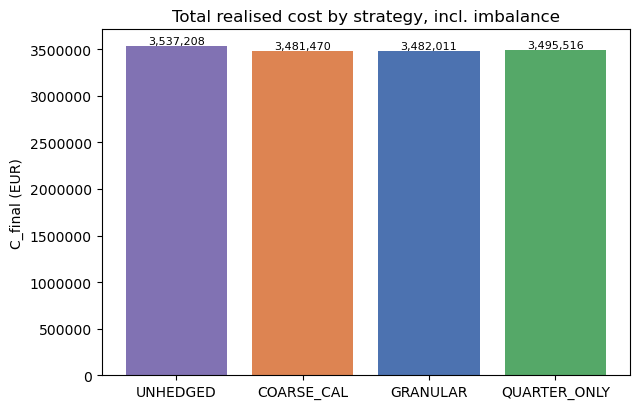

In [15]:
fig, ax = plt.subplots(figsize=(6.5, 4.2))
ax.bar(final_costs_all.index, final_costs_all["C_final_EUR"],
       color=[COLORS[s] for s in final_costs_all.index])
ax.set_ylabel("C_final (EUR)"); ax.set_title("Total realised cost by strategy, incl. imbalance")
ax.ticklabel_format(style="plain", axis="y")
for i, v in enumerate(final_costs_all["C_final_EUR"]):
    ax.text(i, v, f"{v:,.0f}", ha="center", va="bottom", fontsize=8)
plt.tight_layout(); plt.show()

## 7. Conclusion

**Ex-ante shape risk is nearly identical to GRANULAR.** `QUARTER_ONLY`'s RMSE (0.42 MWh/qh) and
residual volume (12,004.94 MWh) are within 0.2% of `GRANULAR`'s (0.42 MWh/qh, 11,985.15 MWh) -
merging Q1's three month-blocks into one quarter-block barely moves the hedge's fit against the
(smooth, HPFC-based) forecast load. Judged only on that ex-ante metric, coarsening Q1 looks close
to free.

**Realised 2024 cost tells a different story.** `QUARTER_ONLY` costs **3,495,515.63 EUR**, which is
**13,504.45 EUR more than `GRANULAR`** (3,482,011.18 EUR) and **14,045.15 EUR more than
`COARSE_CAL`** (3,481,470.48 EUR) - making it the most expensive of the three hedged strategies
this year, even though it still saves 41,692.20 EUR over `UNHEDGED`. The reason is not shape risk:
it is that `GRANULAR`'s three separate Q1 futures (M01 75.32/88.68, M02 60.09/70.59, M03
63.45/72.79 EUR/MWh Base/Peak) lock in three different price levels, while `QUARTER_ONLY` locks in
one blended Q1 price (66.42/77.70). Both are value-neutral against the same HPFC by construction,
so this difference is invisible to the Section 4 risk metrics - it only shows up once the residual
is priced against how 2024's Day-Ahead prices actually moved *within* Q1, month by month.

**Take-away.** For this case, fewer trades were not free: the extra granularity in Q1 that
`GRANULAR` keeps (and `QUARTER_ONLY` gives up) earned back roughly 13.5k EUR this particular year -
about 0.4% of the annual procurement cost, small in relative terms but a reminder that ex-ante
shape-risk metrics computed against the HPFC (a smoothed, historical-shape curve) can understate
how much a coarser block structure gives up once real, month-specific price movements are
realised. `QUARTER_ONLY` remains a reasonable simplification (8 traded series vs. 12, and Q1 is
liquid enough to trade directly per Section 2) - just not a free one.

## 8. Save the extension result

In [16]:
q_positions.to_csv(f"{DATA}/quarter_only_positions.csv", index=False)
final_costs_all.rename_axis("strategy").reset_index().to_csv(f"{DATA}/quarter_only_costs.csv", index=False)

print("saved:", f"{DATA}/quarter_only_positions.csv", q_positions.shape)
print("saved:", f"{DATA}/quarter_only_costs.csv", final_costs_all.shape)

saved: ../data/quarter_only_positions.csv (4, 5)
saved: ../data/quarter_only_costs.csv (4, 7)
